# Import Library and Load Model

In [1]:
from discode import models, utils
model_path = "../weights/weights.pt" # please specify the model weight path
model = models.load(model_path) # if gpu available, it will automatically load on gpu
model.eval() # Model must be specified "eval"

TransformerClassifier(
  (transformer_encoder): TransformerEncoder(
    (layers): ModuleList(
      (0-7): 8 x TransformerEncoderLayer(
        (self_attn): MultiheadAttention(
          (out_proj): NonDynamicallyQuantizableLinear(in_features=480, out_features=480, bias=True)
        )
        (linear1): Linear(in_features=480, out_features=480, bias=True)
        (dropout): Dropout(p=0.1, inplace=False)
        (linear2): Linear(in_features=480, out_features=480, bias=True)
        (norm1): LayerNorm((480,), eps=1e-05, elementwise_affine=True)
        (norm2): LayerNorm((480,), eps=1e-05, elementwise_affine=True)
        (dropout1): Dropout(p=0.1, inplace=False)
        (dropout2): Dropout(p=0.1, inplace=False)
      )
    )
  )
  (fc1): Linear(in_features=480, out_features=96, bias=True)
  (fc2): Linear(in_features=96, out_features=2, bias=True)
)

# Make Accession and Sequence as Variable

In [2]:
# Q9K3J3 is Streptomyces coelicolor malate dehydrogenase
name, sequence = "Q9K3J3", "MTRTPVNVTVTGAAGQIGYALLFRIASGQLLGADVPVKLRLLEITPALKAAEGTAMELDDCAFPLLQGIEITDDPNVAFDGANVALLVGARPRTKGMERGDLLEANGGIFKPQGKAINDHAADDIKVLVVGNPANTNALIAQAAAPDVPAERFTAMTRLDHNRALTQLAKKTGSTVADIKRLTIWGNHSATQYPDIFHATVAGKNAAETVNDEKWLADEFIPTVAKRGAAIIEARGASSAASAANAAIDHVYTWVNGTAEGDWTSMGIPSDGSYGVPEGIISSFPVTTKDGSYEIVQGLDINEFSRARIDASVKELSEEREAVRGLGLI"

# Predict the label of wildtype sequence

In [3]:
# The sequence data will be preprocessed with ESM2-t12 model
data = utils.tokenize_and_dataloader(name, sequence)

# The processed data will be transferred into model, and predict the probability, attention weights, and outlier residues
# The default threshold for selecting outliers is set to 2S
outlier_idx, probability, predicted_label, _name, attention_weights = utils.model_prediction(data, model, threshold="2S")

Loading ESM model...


In [4]:
# The first column of probability is NAD probability, and the second column is NADP probability
print(f"The label probability of NAD is {probability.numpy()[0]:.3f}, NADP is {probability.numpy()[1]:.3f}")

The label probability of NAD is 0.999, NADP is 0.001


# Plot the attention sum and outlier residues

The maximum attention sum is ... 1637.550
The threshold was ... 2S
The outlier residues are ... ['A14', 'E43', 'I44', 'T45', 'G89']
The attention sum of A14 is ... 1251.162
The attention sum of E43 is ... 624.561
The attention sum of I44 is ... 1637.550
The attention sum of T45 is ... 429.931
The attention sum of G89 is ... 397.791


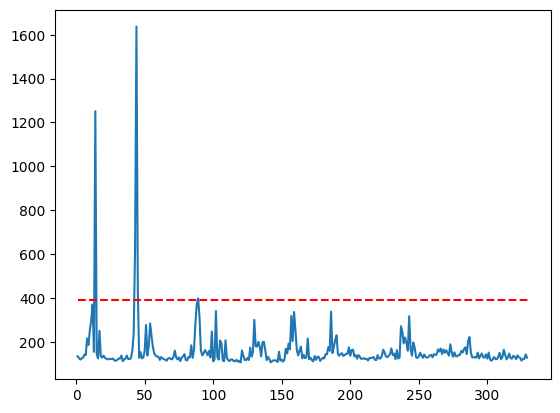

In [5]:
# The default threshold for selecting outliers is set to 2S
utils.plot_attention_sum(attention_weights, sequence, threshold="2S")

# Changes in outlier residues based on supporting different thresholds

In [6]:
# The supported thresholds are as follows, with the default set to S2.
threshold_list = ["1S", "2S", "3S", "IQR", "P90", "P95", "P99"]
for threshold in threshold_list:
    outlier_idx, _, _, _, _ = utils.model_prediction(data, model, threshold=threshold)
    print(f"{threshold} : {len(outlier_idx)} outliers, {outlier_idx}")

1S : 18 outliers, [ 10  11  13  42  43  44  50  53  86  87  88  89 101 129 156 158 185 242]
2S : 5 outliers, [13 42 43 44 88]
3S : 3 outliers, [13 42 43]
IQR : 31 outliers, [  7   9  10  11  13  16  41  42  43  44  50  53  54  86  87  88  89  98
 101 129 156 158 159 168 185 189 236 237 239 242 286]
P90 : 33 outliers, [  7   9  10  11  13  16  41  42  43  44  50  53  54  86  87  88  89  98
 101 108 129 156 158 159 168 185 188 189 236 237 239 242 286]
P95 : 17 outliers, [ 10  11  13  42  43  44  53  86  87  88  89 101 129 156 158 185 242]
P99 : 4 outliers, [13 42 43 44]


# Shortest-mode based mutation design

In [7]:
# The shortest method facilitates efficient exploration of designs for numerous outliers.
short = utils.scan_switch_mutation(model = model,
                                   max_num_mutation = 5,
                                   name = name,
                                   sequence = sequence,
                                   mode = "shortest",
                                   threshold = "IQR")
short

The wildtype label probability is ...tensor([9.9906e-01, 9.3002e-04])
--- Mutation Step 1 Start ---
Generated 589 candidates. Predicting in batches...
Processing 589 candidates in batches of 32


Processing batches:   0%|          | 0/19 [00:00<?, ?batch/s]

Batch processing completed
Step 1 finished. Converted: 0
--- Mutation Step 2 Start ---
Generated 520 candidates. Predicting in batches...
Processing 520 candidates in batches of 32


Processing batches:   0%|          | 0/17 [00:00<?, ?batch/s]

Batch processing completed
Step 2 finished. Converted: 1
Mutation found. Stopping.


,NAD,NADP
Q9K3J3;E43S;I44R,0.29275,0.693554


# Iter_num-mode based mutation design

In [8]:
# When using the "iter" mode, strict thresholds like Z=3 and 0.99 are recommended for selecting a smaller number of outliers to manage design complexity
# When a switching design is obtained, scan only the combinations with the same number of mutations
iter_num = utils.scan_switch_mutation(model = model,
                                      max_num_mutation = 3,
                                      name = name,
                                      sequence = sequence,
                                      mode = "iter_num",
                                      threshold = "P99")
iter_num

The wildtype label probability is ...tensor([9.9906e-01, 9.3002e-04])
--- Mutation Step 1 Start ---
Generated 76 candidates. Predicting in batches...
Processing 76 candidates in batches of 32


Processing batches:   0%|          | 0/3 [00:00<?, ?batch/s]

Batch processing completed
Step 1 finished. Converted: 0
--- Mutation Step 2 Start ---
Generated 3774 candidates. Predicting in batches...
Processing 3774 candidates in batches of 32


Processing batches:   0%|          | 0/118 [00:00<?, ?batch/s]

Batch processing completed
Step 2 finished. Converted: 3
Mutation found. Stopping.


,NAD,NADP
Q9K3J3;E43S;I44R,0.292750,0.693554
Q9K3J3;E43A;I44S,0.369836,0.621954
Q9K3J3;E43V;I44S,0.466169,0.516355


# Iter_prob-mode based mutation design

In [9]:
# Scan all combinations of mutations
iter_prob = utils.scan_switch_mutation(model = model,
                                       max_num_mutation = 3,
                                       name = name,
                                       sequence = sequence,
                                       mode = "iter_prob",
                                       threshold = "3S")
iter_prob

The wildtype label probability is ...tensor([9.9906e-01, 9.3002e-04])
--- Mutation Step 1 Start ---
Generated 57 candidates. Predicting in batches...
Processing 57 candidates in batches of 32


Processing batches:   0%|          | 0/2 [00:00<?, ?batch/s]

Batch processing completed
Step 1 finished. Converted: 0
--- Mutation Step 2 Start ---
Generated 1536 candidates. Predicting in batches...
Processing 1536 candidates in batches of 32


Processing batches:   0%|          | 0/48 [00:00<?, ?batch/s]

Batch processing completed
Step 2 finished. Converted: 3
--- Mutation Step 3 Start ---
Generated 31138 candidates. Predicting in batches...
Processing 31138 candidates in batches of 32


Processing batches:   0%|          | 0/974 [00:00<?, ?batch/s]

Batch processing completed
Step 3 finished. Converted: 278


,NAD,NADP
Q9K3J3;A14W;E43S;I44R,0.032465,0.966879
Q9K3J3;A14S;E43S;I44R,0.032607,0.966522
Q9K3J3;A14F;E43S;I44R,0.034141,0.965143
Q9K3J3;A14T;E43S;I44R,0.034261,0.965122
Q9K3J3;A14N;E43S;I44R,0.041275,0.957841
Q9K3J3;A14H;E43S;I44R,0.041669,0.957238
Q9K3J3;A14N;E43A;I44S,0.044068,0.956941
Q9K3J3;A14R;E43S;I44R,0.042003,0.956790
Q9K3J3;A14Y;E43S;I44R,0.043529,0.955419
Q9K3J3;A14T;E43A;I44S,0.048458,0.952406
